# 2.1

Shape of observations: (15,)

Running Adaptive Metropolis algorithm for 1000 iterations...
Initial proposal distribution (first 100 iterations): N(q_prev, D) with D = diag([0.01, 2e-10])
AM parameters: sp = 2.38^2/2 = 2.8322, k0 = 100
Shape of observations: (15,)
sapesle (1000, 3)
am,san (1000, 3)

Final acceptance rate: 0.732

PROBLEM 2.1 RESULTS

At k=101, the new Vk generated from the first 100 samples is:
Vk = [[ 1.14064308e-01 -3.97322270e-06]
 [-3.97322270e-06  9.48250945e-10]]

PROBLEM 2.2 RESULTS

At k=M, the final Vk generated is:
Vk = [[1.26217874e+00 2.00389379e-05]
 [2.00389379e-05 1.85205907e-09]]

Computing posterior values for MAP estimate...

Computing posterior values for MAP estimate...
SHAPE (1000, 3)

PROBLEM 1.1 RESULTS

MAP Estimate (q_MAP):
  Φ = -18.828741 W/cm²
  h = 0.001960 W/cm²/°C
  π(υ|q_MAP)π0(q_MAP) = 3.12e-05

Posterior Distribution π(q|υ) Summary:
Φ:
  Mean = -18.495390 W/cm²
  Std  = 1.075134 W/cm²
  95% CI = [-19.586676, -15.470232]

h:
  Mean = 1.97

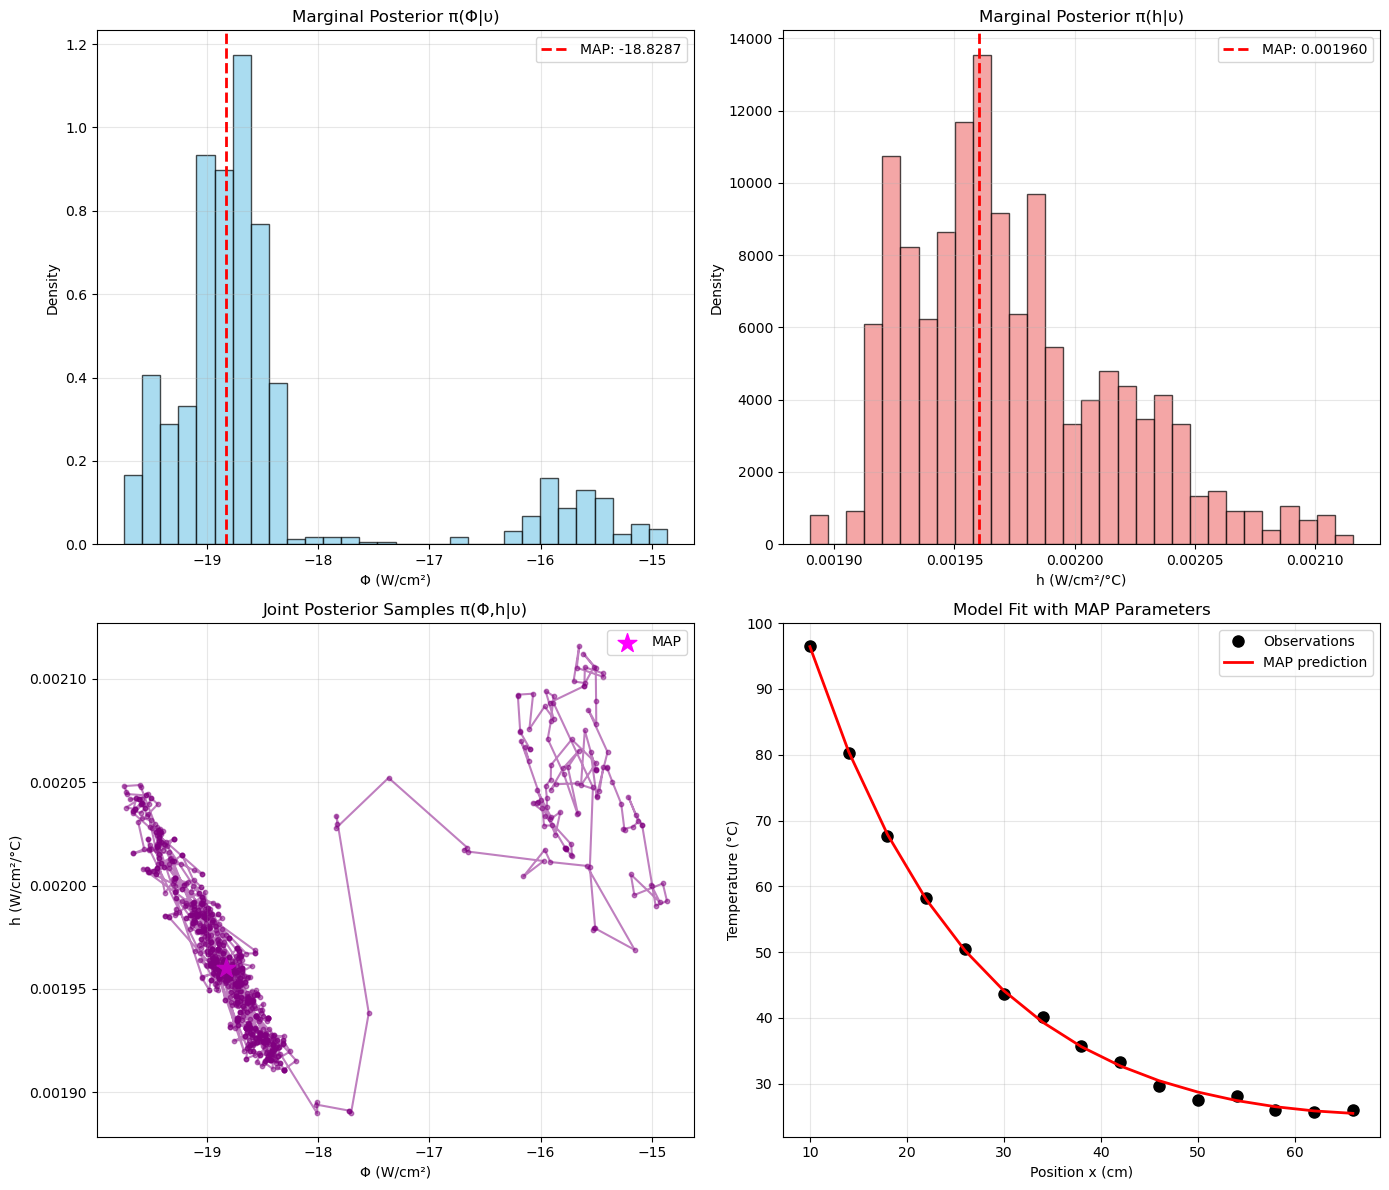


Results saved to 'problem2.1_results.npz'


0.7317317317317318

In [16]:
from am_mcmc import *
M=1000
samples, posterior_values, q_map, Vk_at_101, acceptance_rate \
    = run_adaptive_metropolis_for_heat_equation(M = M, func = 'dram', k_for_am = 100, burn = 0, title = '2_1_DRAM_Gibbs', data_filename='HW06_Problem3.mat')

# Save results
np.savez('problem2.1_results.npz',
            samples=samples,
            q_map=q_map,
            posterior_values=posterior_values,
            acceptance_rate=acceptance_rate)

print(f"\nResults saved to 'problem2.1_results.npz'")
acceptance_rate

In [17]:
samples[np.argmax(posterior_values[300:])] # accounting for burn-in when selecting MAP

array([-1.91924390e+01,  1.99026992e-03,  2.96898766e-01])

MAP point: [Φ = -19.2 W/cm²,  h = 0.00199 W/cm²/°C]

(Final) Acceptance Ratio: 0.73


### Note:
please ignore 95% CI in above output, the credible interval for part 2.2 is below.


# 2.2



In [18]:
ALPHA = .05
c = int((M*ALPHA)/2) # note, this introduces some rounding error when C is non-integer value

sorted_phi = np.sort(samples[:,0])
sorted_h = np.sort(samples[:,1])
sorted_sigma = np.sort(samples[:,2])
CI_phi = (sorted_phi[c-1], sorted_phi[-c])
CI_h = (sorted_h[c-1], sorted_h[-c])
CI_sigma = (sorted_sigma[c-1], sorted_sigma[-c])




Text(0.5, 1.0, 'Range of Phi Samples: Phi vs (sorted) MCMC sample index')

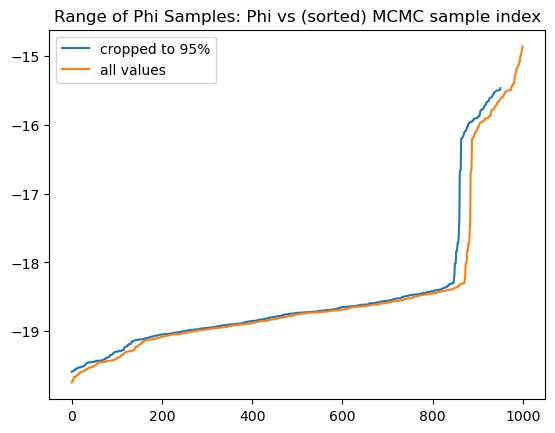

In [19]:
plt.plot(sorted_phi[c-1:-c], label ="cropped to 95%")
plt.plot(sorted_phi, label ="all values")
plt.legend()
plt.title("Range of Phi Samples: Phi vs (sorted) MCMC sample index")

Text(0.5, 1.0, 'Range of h Samples: h vs (sorted) MCMC sample index')

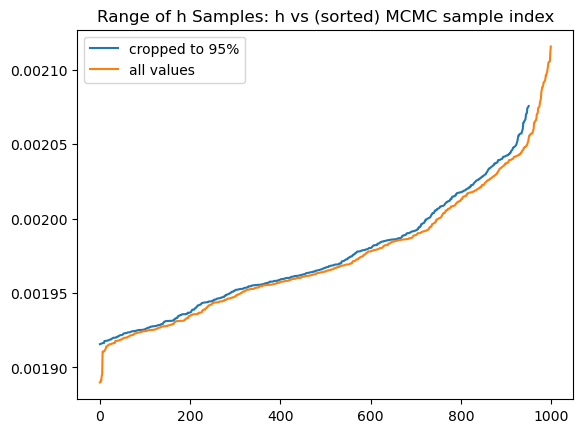

In [20]:
plt.plot(sorted_h[c-1:-c], label ="cropped to 95%")
plt.plot(sorted_h, label ="all values")
plt.legend()
plt.title("Range of h Samples: h vs (sorted) MCMC sample index")

Text(0.5, 1.0, 'Range of sigma Samples: sigma vs (sorted) MCMC sample index')

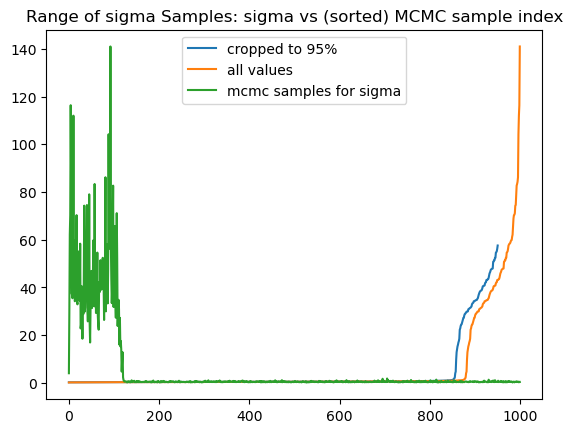

In [21]:
plt.plot(sorted_sigma[c-1:-c], label ="cropped to 95%")
plt.plot(sorted_sigma, label ="all values")
plt.plot(samples[:,2], label = 'mcmc samples for sigma')
plt.legend()
plt.title("Range of sigma Samples: sigma vs (sorted) MCMC sample index")

In [22]:

print(f"Credible Interval for Phi: [{CI_phi[0]:.3f}, {CI_phi[1]:.3f}]")
print(f"Credible Interval for h: [{CI_h[0]:.5f}, {CI_h[1]:.5f}]")
print(f"Credible Interval for Sigma_0^2: [{CI_sigma[0]:.3f}, {CI_sigma[1]:.3f}]")

Credible Interval for Phi: [-19.587, -15.441]
Credible Interval for h: [0.00192, 0.00208]
Credible Interval for Sigma_0^2: [0.191, 57.985]


# 2.3
Running the full DRAM algorithm produces several important improvements compared to using only Metropolis-Hastings with Gibbs step for variance estimation:

1. Improved Mixing and Convergence
Faster burn-in: The adaptive component learns the covariance structure of the target distribution on-the-fly, allowing the chain to reach the high-probability region more quickly (and adapt to local landscape). 
Generally, the autocorrelation time is substantially lower with DRAM, meaning each sample provides more independent information about the posterior. 

2. Enhanced Exploration Efficiency
Higher effective acceptance rate: While the raw acceptance ratio might appear similar, DRAM's delayed rejection component salvages proposals that would otherwise be rejected, particularly in the second stage with the scaled proposal.
This allows for better handling of complex geometries: DRAM excels with non-linear, correlated, or constrained parameter spaces.

3. More Reliable Uncertainty Quantification
More accurate credible intervals: The DRAM chain provides better coverage of the true posterior, particularly for the variance parameter $\sigma_0^2$, which often has a skewed distribution.
Reduced sensitivity to initial proposals: Unlike standard MH, DRAM is robust to poor initial proposal tuning because the adaptive component corrects the covariance during burn-in. 

4. Specific Improvements for HW06 Problem 3
Given that Problem 3 involves unknown observation errors, DRAM provides:
Better estimation of $\sigma_0^2$: The adaptive component learns the scale of the error variance more effectively
Reduced correlation between $\Phi$, $h$, and $\sigma_0^2$: The adaptive covariance matrix helps decorrelate these parameters in the proposal distribution, improving sampling efficiency

To summarize, with the full DRAM algorithm, the Adaptive Metropolis component updates the proposal covariance using the empirical covariance of the chain, allowing the proposal distribution to better approximate the posterior geometry. This improves the exploration of the parameter space and increases sampling efficiency. Additionally, Delayed Rejection allows a second proposal when the first proposal is rejected, which reduces the probability that the chain remains stuck in a particular region. From a prior vs. data perspective, the DRAM algorithm allows the chain to more quickly move away from the initial prior-dominated region and into the region where the likelihood (i.e., the information from the data) dominates the posterior distribution. Consequently, the MAP estimate and credible intervals are generally more stable and better represent the information contained in the observations.